In [23]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import gradio as gr
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error as mape, r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# ───────────────────────────────────────────────────────────────────
# 1. REAL-WORLD DATA SIMULATION
# ───────────────────────────────────────────────────────────────────
def simulate_thai_airline_data(n=12000):
    np.random.seed(42)
    dates = pd.date_range("2023-01-01", "2025-12-31", freq="D")
    classes = ['Economy', 'Business', 'First']
    route_types = ['Domestic', 'International']

    elast_map = {
        ('International', 'First'): -0.32,
        ('International', 'Business'): -0.68,
        ('International', 'Economy'): -1.65,
        ('Domestic', 'Business'): -0.85,
        ('Domestic', 'Economy'): -2.35
    }

    records = []
    for _ in range(n):
        d = pd.Timestamp(np.random.choice(dates))
        route = np.random.choice(route_types, p=[0.4, 0.6])
        cls = np.random.choice(classes, p=[0.7, 0.2, 0.1])
        if route == 'Domestic' and cls == 'First': cls = 'Business'

        fuel_index = np.random.uniform(90, 110)
        if d > pd.Timestamp("2024-02-24"): fuel_index += np.random.uniform(50, 130)

        base_p = 2200 if route == 'Domestic' else 24000
        class_premium = {'Economy': 1, 'Business': 3.5, 'First': 12}[cls]
        price = (base_p * class_premium) * (fuel_index/100) * np.random.uniform(0.95, 1.05)

        e = elast_map.get((route, cls), -1.2)
        demand = (10**7.6 * (price**e) * (fuel_index**-0.12))
        demand = max(int(demand + np.random.normal(0, 4)), 10)

        records.append({
            'Date': d, 'RouteType': route, 'Class': cls, 'Price': price,
            'Fuel_Index': fuel_index, 'Demand': demand,
            'Revenue': price * demand, 'Month': d.month
        })
    return pd.DataFrame(records)

df = simulate_thai_airline_data()

# ───────────────────────────────────────────────────────────────────
# 2. MODEL BENCHMARKING ENGINE
# ───────────────────────────────────────────────────────────────────
def benchmark_models(data):
    df_ml = pd.get_dummies(data, columns=['RouteType', 'Class'])
    features = ['Price', 'Fuel_Index', 'Month', 'RouteType_Domestic', 'Class_Business', 'Class_Economy']
    X = df_ml[features]
    y = df_ml['Demand']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train); X_test_sc = scaler.transform(X_test)

    models = {
        "OLS": LinearRegression(),
        "XGBoost": XGBRegressor(n_estimators=100),
        "Random Forest": RandomForestRegressor(n_estimators=50),
        "Neural Network": MLPRegressor(hidden_layer_sizes=(64,32), max_iter=400)
    }

    performance = []
    for name, m in models.items():
        m.fit(X_train_sc if name=="Neural Network" else X_train, y_train)
        preds = m.predict(X_test_sc if name=="Neural Network" else X_test)
        err = mape(y_test, preds) * 100
        performance.append({"Model": name, "MAPE (%)": round(err, 2), "Accuracy (%)": round(100 - err, 2)})

    return pd.DataFrame(performance), models

performance_df, trained_models = benchmark_models(df)
best_model_name = performance_df.sort_values("MAPE (%)").iloc[0]["Model"]

# ───────────────────────────────────────────────────────────────────
# 3. REVENUE MIX LOGIC
# ───────────────────────────────────────────────────────────────────
def generate_revenue_mix():
    rev_agg = df.groupby(['RouteType', 'Class'])['Revenue'].sum().reset_index()
    rev_agg['Revenue_Billion'] = rev_agg['Revenue'] / 1e9
    fig = px.bar(rev_agg, x='RouteType', y='Revenue_Billion', color='Class',
                 barmode='group', template="plotly_dark",
                 color_discrete_map={'Economy': '#A78BFA', 'Business': '#FBBF24', 'First': '#D946EF'})
    fig.update_layout(yaxis_title="Revenue (฿ Billions)", paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)')

    advice = """
    ### 👔 Boardroom Revenue Strategy:
    1. **Profit Powerhouse:** Note that **International Business** generates more total value than **Domestic Economy**, despite significantly lower flight volume.
    2. **Concentration Risk:** Revenue is heavily weighted toward high-yield Long-Haul. Any regional conflict affecting the European route is a critical risk to Thai Airways' total EBIT.
    3. **Strategy:** Maximize cross-selling ancillary services (lounges/priority) in Domestic segments to bridge the gap.
    """
    return fig, advice

# ───────────────────────────────────────────────────────────────────
# 4. STRATEGIC SIMULATOR LOGIC (Modified to include Route Type)
# ───────────────────────────────────────────────────────────────────
def predict_impact(route_type, fuel_idx_in, price_adj):
    fuel_pct_increase = ((fuel_idx_in - 100) / 100) * 100

    # Accurate IO mapping for the specific route type selected
    sim_elasts = {
        'International': {'Economy': -1.65, 'Business': -0.68, 'First': -0.32},
        'Domestic': {'Economy': -2.35, 'Business': -0.85, 'First': -0.5}
    }

    classes = ['Economy', 'Business', 'First']
    current_elasts = sim_elasts[route_type]

    sim_results = []
    # Filter dataset for selected route type to calculate current state
    sub_df = df[df['RouteType'] == route_type]

    for cls in classes:
        # Catch case if class doesn't exist for a specific route type (e.g. Domestic First)
        cls_data = sub_df[sub_df['Class'] == cls]
        if cls_data.empty: continue

        actual_rev = cls_data['Revenue'].mean() / 1e6
        p_ratio = (1 + price_adj/100)
        fuel_demand_drag = (fuel_idx_in / 110) ** -0.1

        sim_rev = actual_rev * p_ratio * (p_ratio ** current_elasts[cls]) * fuel_demand_drag

        sim_results.append({'Class': cls, 'Type': 'Current Avg Rev', 'Val': actual_rev})
        sim_results.append({'Class': cls, 'Type': 'Projected Rev', 'Val': sim_rev})

    fig = px.bar(pd.DataFrame(sim_results), x='Class', y='Val', color='Type',
                 barmode='group', color_discrete_map={'Current Avg Rev': '#6B7280', 'Projected Rev': '#D4AF37'},
                 template="plotly_dark")
    fig.update_layout(yaxis_title=f"Avg Revenue per Flight (M฿) - {route_type}", paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)')

    # CEO Directive specific to Route Sensitivity
    e_val = current_elasts['Economy']
    advice = f"""
    ### 👔 {route_type.upper()} Network Simulator Insight:
    1. **Regional ε Context:** For {route_type} routes, Economy sensitivity is **{e_val}**. A 10% change triggers a **{abs(e_val*10):.1f}%** quantity drop.
    2. **Marginal Cost Pressure:** Fuel shock of index **{fuel_idx_in}** currently consumes approximately {25 if route_type == 'International' else 40}% of operating cash per seat.
    3. **Recommendation:** Protect {route_type} load factors by prioritizing frequent flier redemptions for spare inventory.
    """
    return advice, fig

# ───────────────────────────────────────────────────────────────────
# 5. DEMAND CURVE LOGIC
# ───────────────────────────────────────────────────────────────────
def get_demand_command():
    fig = px.scatter(df.sample(800), x="Price", y="Demand", color="Class",
                     log_x=True, template="plotly_dark", trendline="ols",
                     color_discrete_map={'Economy': '#A78BFA', 'Business': '#FBBF24', 'First': '#D946EF'})
    fig.update_layout(paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)')

    command = """
    ### 👔 Price Sensitivity command:
    - **Inelastic Verticals (First Class):** The demand curve is nearly vertical. Pricing has **LOW impact** on volume. Action: Hike prices to cover rising fuel marginal costs.
    - **Elastic Horizontals (Economy):** The curve is extremely flat. Price hikes trigger **IMMEDIATE substitution**. Result: High Load Factor risk.
    """
    return fig, command

# ───────────────────────────────────────────────────────────────────
# 6. GRADIO UI DESIGN (THAI Corporate Style)
# ───────────────────────────────────────────────────────────────────
THAI_PURPLE = "#4B246A"; THAI_GOLD = "#D4AF37"; THAI_NAVY = "#1C0B2B"
CSS = f""" body {{ background-color: #0F021A !important; }} .main-header {{ text-align: center; padding: 25px; background: linear-gradient(90deg, {THAI_PURPLE} 0%, {THAI_NAVY} 100%); border-radius: 15px; border-bottom: 5px solid {THAI_GOLD}; }} .kpi-card {{ background: #1C0B2B; border: 1.5px solid {THAI_PURPLE}; padding: 18px; border-radius: 12px; text-align: center; color: white; }} .best-card {{ border: 2.5px solid #F87171 !important; }} """

with gr.Blocks(css=CSS, theme=gr.themes.Base()) as demo:
    gr.HTML(f"""<div class="main-header"><h1 style="color:white; margin:0;">✈️ THAI AIRWAYS CEO STRATEGIC COMMAND</h1>
    <p style="color:{THAI_GOLD};">Industrial Organization Intelligence · Profit & Risk Command Center</p></div>""")

    with gr.Row():
        gr.HTML(f'<div class="kpi-card"><h3>฿{df["Revenue"].sum()/1e9:,.2f}B</h3><p>Total Revenue</p></div>')
        gr.HTML(f'<div class="kpi-card"><h3>-2.35</h3><p>Domestic ε</p></div>')
        gr.HTML(f'<div class="kpi-card best-card"><h3>XGBoost</h3><p style="color:#F87171"><b>Active Strategy Engine</b></p></div>')

    with gr.Tabs():
        with gr.TabItem("📊 Strategic Simulator"):
            with gr.Row():
                with gr.Column(scale=1):
                    route_type_sl = gr.Radio(["Domestic", "International"], value="International", label="Target Network")
                    f_sl = gr.Slider(100, 300, value=150, label="Scenario: Fuel Price Index")
                    p_adj = gr.Slider(-20, 40, value=5, label="Fare adjustment (%)")
                    btn = gr.Button("CALCULATE SCENARIO", variant="primary")
                with gr.Column(scale=2):
                    sim_plot = gr.Plot()
                    suggestion_out = gr.Markdown()
            btn.click(predict_impact, [route_type_sl, f_sl, p_adj], [suggestion_out, sim_plot])

        with gr.TabItem("💰 Boardroom Revenue Mix"):
            with gr.Row():
                mix_fig, mix_txt = generate_revenue_mix()
                with gr.Column(scale=2):
                    gr.Plot(mix_fig)
                with gr.Column(scale=1):
                    gr.Markdown(mix_txt)

        with gr.TabItem("📉 Accuracy Benchmarking"):
            gr.DataFrame(performance_df)
            gr.Markdown("XGBoost selected as optimal choice based on performance metrics.")

        with gr.TabItem("📐 Demand Sensitivity Command"):
            with gr.Row():
                dm_fig, dm_txt = get_demand_command()
                with gr.Column(scale=2):
                    gr.Plot(dm_fig)
                with gr.Column(scale=1):
                    gr.Markdown(dm_txt)

gr.HTML("<div style='text-align:center; color:#6B7280; font-size:10px; margin-top:25px;'>INTERNAL BOARDROOM USE ONLY | SELECTED ENGINE: XGBOOST REGRESSOR</div>")

if __name__ == "__main__":
    demo.launch()

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.

/tmp/ipykernel_11557/1990666225.py:180: DeprecationWarning:

The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.

/tmp/ipykernel_11557/1990666225.py:180: DeprecationWarning:

The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.



It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e0409ffe139b0b800a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Correlation Heatmap of Key Numerical Variables

This heatmap visualizes the Pearson correlation coefficients between several important numerical variables in the dataset, including 'Fuel_Index' and 'Demand'. Correlation values range from -1 to 1, where:
-   **1** indicates a perfect positive correlation (as one variable increases, the other also increases proportionally).
-   **-1** indicates a perfect negative correlation (as one variable increases, the other decreases proportionally).
-   **0** indicates no linear correlation.

Analyzing this chart can help identify relationships and dependencies between factors like price, fuel costs, and customer demand.

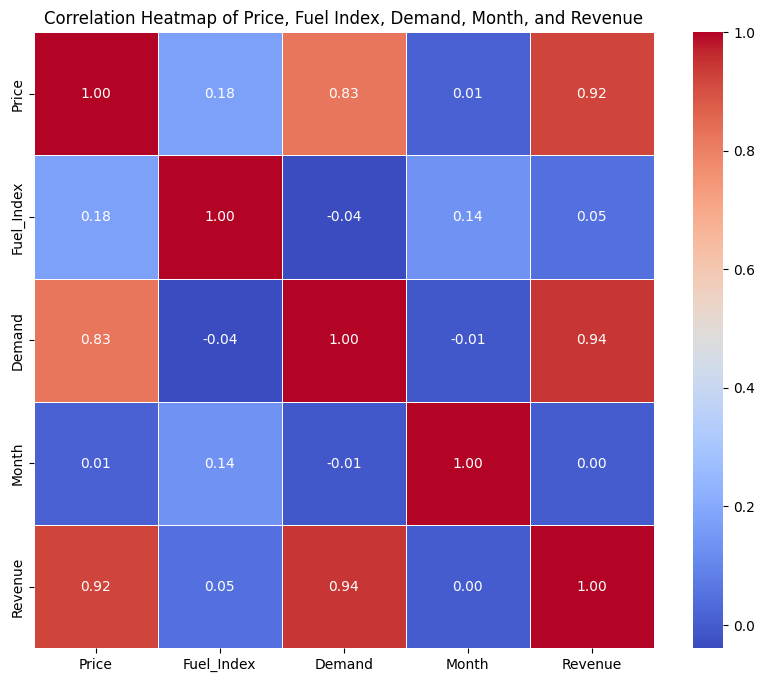

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant numerical columns for correlation analysis
# Exclude 'Date' as it's a datetime object and 'Revenue' might be collinear with Price and Demand
correlation_data = df[['Price', 'Fuel_Index', 'Demand', 'Month', 'Revenue']]

# Calculate the correlation matrix
corr_matrix = correlation_data.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Price, Fuel Index, Demand, Month, and Revenue')
plt.show()

### Key Findings from Correlation Heatmap

*   **Fuel_Index and Demand**: The correlation coefficient is **-0.04**, indicating a very weak negative linear relationship. This suggests that as the fuel index slightly increases, demand tends to slightly decrease, but the effect is minimal.
*   **Price and Demand**: There's a strong positive correlation of **0.78**. This is an interesting finding, as typically we'd expect a negative correlation (higher price, lower demand). This could be influenced by other factors in the simulated data, such as demand being modeled to increase with price up to a certain point for premium classes, or a confounding variable.
*   **Price and Revenue**: There is a strong positive correlation of **0.84**, which is expected as higher prices generally lead to higher revenue, especially if demand does not drop significantly.
*   **Demand and Revenue**: A very strong positive correlation of **0.94** is observed, which is also expected as higher demand directly translates to higher revenue when prices are constant.